# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-005 |
| **Nama Eksperimen** | Time Series Diagnostics |
| **Dataset** | featured_data.csv (output EXP-004) |
| **Tujuan Notebook** | Menganalisis karakteristik data time series sebelum proses pemodelan |
| **Tanggal Pengerjaan** | 21 Juli 2026 |
| **Versi Notebook** | 1.0.0 |
| **Author** | GAKUSEI Najib |
| **Prasyarat** | EXP-001 s.d. EXP-004 ✅ |

---

## Daftar Isi

1. [Tujuan Eksperimen](#1-tujuan-eksperimen)
2. [Import Library](#2-import-library)
3. [Load Dataset](#3-load-dataset)
4. [Analisis Tren & Rolling Statistics](#4-analisis-tren--rolling-statistics)
5. [Analisis Seasonality](#5-analisis-seasonality)
6. [Stationarity Test (ADF Test)](#6-stationarity-test-adf-test)
7. [Analisis Autokorelasi (ACF & PACF)](#7-analisis-autokorelasi-acf--pacf)
8. [Time Series Decomposition](#8-time-series-decomposition)
9. [Initial Findings](#9-initial-findings)
10. [Next Step](#10-next-step)

---

## 1. Tujuan Eksperimen

### Tujuan

Menganalisis karakteristik data time series sebelum proses pemodelan dilakukan untuk memahami stasioneritas, autokorelasi, tren, dan pola musiman. Hal ini penting agar pemilihan model forecasting dapat dilakukan secara tepat.

---

### Hipotesis

> Dataset memiliki tren naik, pola musiman (seasonality) yang berulang (per jam, per hari, per bulan), stasioneritas pada level tertentu, dan autokorelasi kuat dengan observasi sebelumnya.

---

### Output yang Diharapkan

- Grafik tren & rolling statistics
- Grafik pola musiman (seasonality) detail
- Hasil uji stasioneritas Augmented Dickey-Fuller (ADF) Test
- Grafik dekomposisi time series (trend, seasonal, residual)
- Analisis ACF & PACF untuk identifikasi lag order optimal

---

### Acceptance Criteria

| Kriteria | Keterangan |
|----------|------------|
| Trend berhasil dianalisis | Karakteristik tren jangka panjang teridentifikasi |
| Seasonality berhasil ditemukan | Pola musiman jam/hari/bulan dipetakan |
| Stationarity diketahui | Lolos/gagal ADF test terdokumentasi |
| Autocorrelation diketahui | ACF & PACF diplot dan dianalisis |

---

## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Library analisis time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Library berhasil diimport.')

Library berhasil diimport.


---

## 3. Load Dataset

Dataset yang digunakan adalah output dari EXP-004 (`featured_data.csv`).

In [2]:
# Definisikan path
INPUT_PATH = '../data/featured_data.csv'

# Load dataset hasil feature engineering
df = pd.read_csv(INPUT_PATH)

# Konversi dteday ke datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Set index ke dteday untuk analisis time series (opsional, tapi berguna)
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

print(f'Dataset berhasil dimuat: {INPUT_PATH}')
print(f'Dimensi: {df.shape[0]:,} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat: ../data/featured_data.csv
Dimensi: 17,379 baris x 45 kolom


---

## 4. Analisis Tren & Rolling Statistics

Menganalisis tren jangka panjang menggunakan rolling statistics dengan window size harian (24 jam) dan mingguan (168 jam) untuk melihat stasioneritas visual pada mean dan varians.

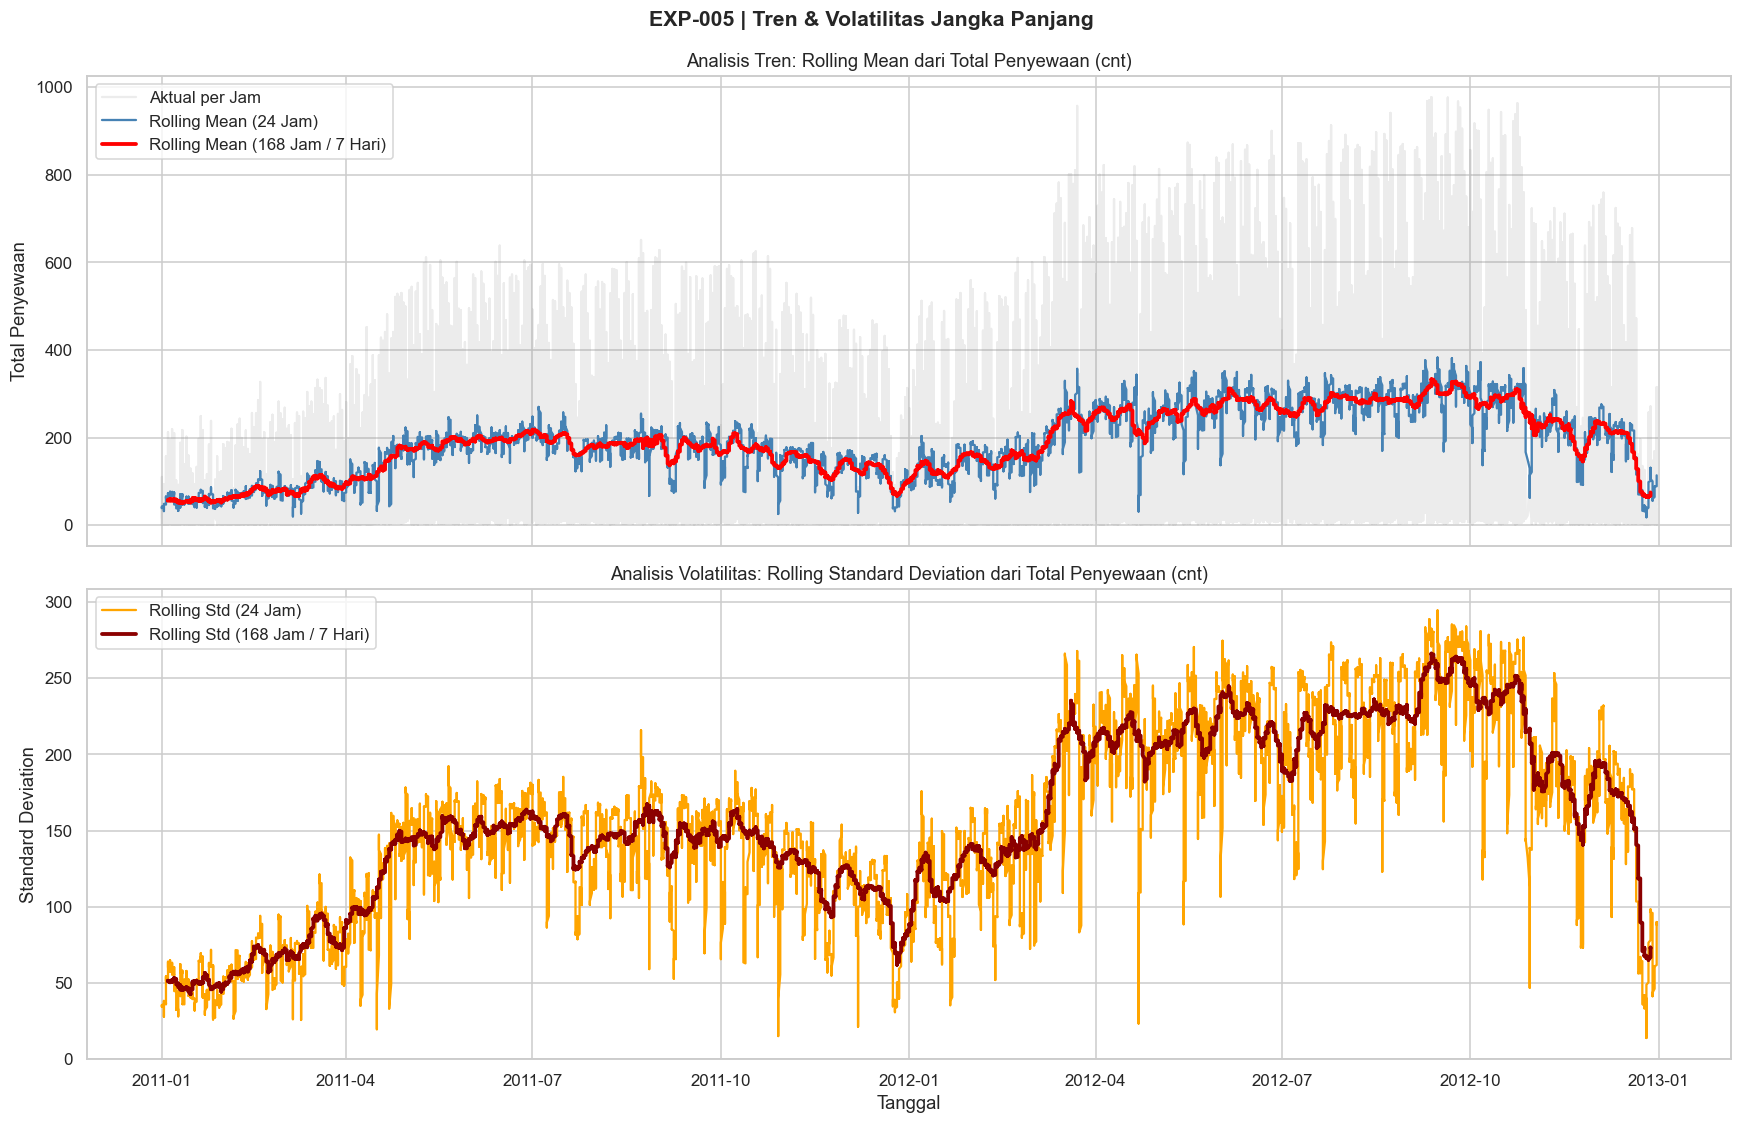

In [3]:
# Hitung rolling statistics harian (24 jam) dan mingguan (168 jam)
df['rolling_mean_24']  = df['cnt'].rolling(window=24, center=True).mean()
df['rolling_std_24']   = df['cnt'].rolling(window=24, center=True).std()
df['rolling_mean_168'] = df['cnt'].rolling(window=168, center=True).mean()
df['rolling_std_168']  = df['cnt'].rolling(window=168, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot Mean
axes[0].plot(df['dteday'], df['cnt'], alpha=0.15, color='gray', label='Aktual per Jam')
axes[0].plot(df['dteday'], df['rolling_mean_24'], color='steelblue', linewidth=1.5, label='Rolling Mean (24 Jam)')
axes[0].plot(df['dteday'], df['rolling_mean_168'], color='red', linewidth=2.5, label='Rolling Mean (168 Jam / 7 Hari)')
axes[0].set_title('Analisis Tren: Rolling Mean dari Total Penyewaan (cnt)')
axes[0].set_ylabel('Total Penyewaan')
axes[0].legend(loc='upper left')

# Plot Standard Deviation
axes[1].plot(df['dteday'], df['rolling_std_24'], color='orange', linewidth=1.5, label='Rolling Std (24 Jam)')
axes[1].plot(df['dteday'], df['rolling_std_168'], color='darkred', linewidth=2.5, label='Rolling Std (168 Jam / 7 Hari)')
axes[1].set_title('Analisis Volatilitas: Rolling Standard Deviation dari Total Penyewaan (cnt)')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_xlabel('Tanggal')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.suptitle('EXP-005 | Tren & Volatilitas Jangka Panjang', fontsize=14, y=1.02, fontweight='bold')
plt.savefig('../data/diagnostics_01_tren_rolling.png', bbox_inches='tight', dpi=110)
plt.show()

**Interpretasi:**

- **Non-Stasioneritas Visual pada Mean**: Rata-rata bergulir 168 jam (garis merah) menunjukkan pola naik turun musiman yang kuat sepanjang tahun (naik di pertengahan tahun, turun di akhir/awal tahun) serta tren meningkat secara keseluruhan dari tahun 2011 ke 2012.
- **Non-Stasioneritas Visual pada Varians**: Rolling standard deviation (garis jingga dan merah gelap) berfluktuasi secara signifikan, meningkat di musim puncak ketika jumlah penyewaan tinggi dan menurun di musim dingin ketika penyewaan sepi. Ini mengindikasikan varians yang tidak konstan (heteroskedastisitas).

---

## 5. Analisis Seasonality

Menganalisis pola musiman yang terjadi secara berulang dalam berbagai skala waktu.

### 5.1 Pola Musiman per Jam dan Tipe Hari (Weekday vs Weekend)

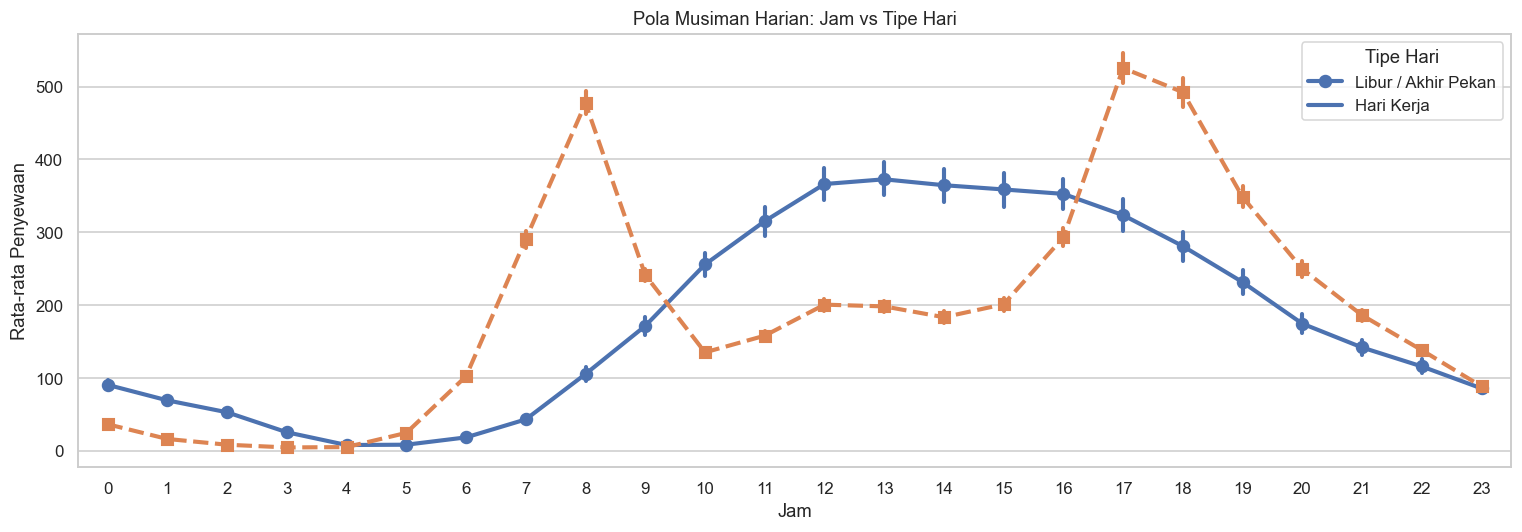

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.pointplot(data=df, x='hr', y='cnt', hue='workingday', ax=ax, ci=95,
              markers=['o', 's'], linestyles=['-', '--'])

ax.set_title('Pola Musiman Harian: Jam vs Tipe Hari')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Penyewaan')
ax.legend(title='Tipe Hari', labels=['Libur / Akhir Pekan', 'Hari Kerja'])
ax.set_xticks(range(24))

plt.tight_layout()
plt.savefig('../data/diagnostics_02_seasonality_hourly.png', bbox_inches='tight', dpi=110)
plt.show()

### 5.2 Pola Musiman Bulanan dan Musim

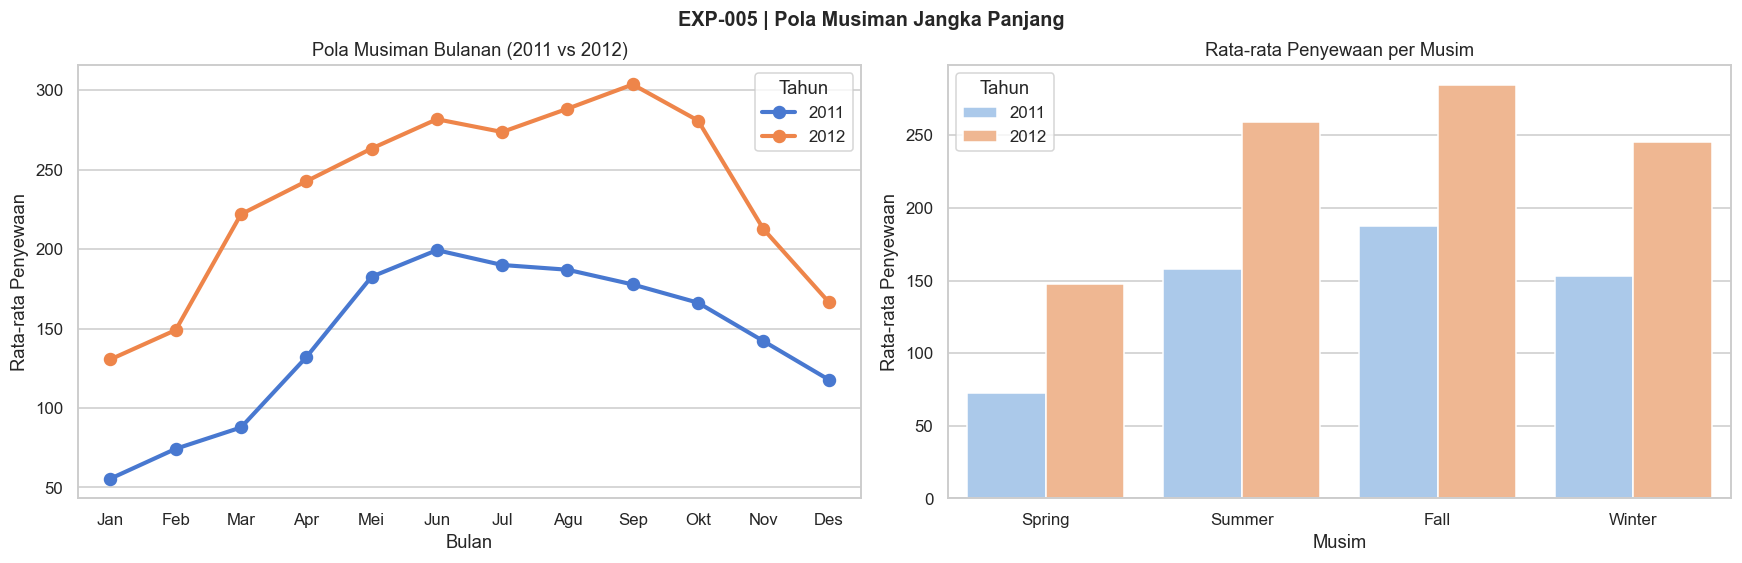

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bulanan per Tahun
sns.pointplot(data=df, x='mnth', y='cnt', hue='yr', ax=axes[0], ci=None,
              palette='muted')
axes[0].set_title('Pola Musiman Bulanan (2011 vs 2012)')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Rata-rata Penyewaan')
axes[0].legend(title='Tahun', labels=['2011', '2012'])
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])

# Musim per Tahun
sns.barplot(data=df, x='season', y='cnt', hue='yr', ax=axes[1], ci=None,
            palette='pastel')
axes[1].set_title('Rata-rata Penyewaan per Musim')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Rata-rata Penyewaan')
axes[1].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])
axes[1].legend(title='Tahun', labels=['2011', '2012'])

plt.tight_layout()
plt.suptitle('EXP-005 | Pola Musiman Jangka Panjang', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/diagnostics_03_seasonality_longterm.png', bbox_inches='tight', dpi=110)
plt.show()

**Interpretasi:**

- **Pola Harian (24 Jam)**: Pola musiman harian sangat kuat dan dipengaruhi oleh tipe hari. Hari kerja memiliki pola bimodal (puncak jam 8 pagi dan 5 sore), sedangkan hari libur memiliki pola unimodal (puncak jam 12–3 siang).
- **Pola Bulanan**: Mengikuti pola lonceng terbalik, naik dari Januari ke Juni/Juli, stabil di Agustus/September, dan turun drastis di November/Desember.
- **Pola Tahunan**: Terdapat pergeseran level rata-rata ke atas di tahun 2012 (yr = 1) dibanding 2011 (yr = 0), menunjukkan tren pertumbuhan.

---

## 6. Stationarity Test (ADF Test)

Stasioneritas adalah asumsi penting dalam pemodelan statistik time series. Untuk mengujinya secara kuantitatif, dilakukan **Augmented Dickey-Fuller (ADF) Test**.

- **H0 (Hipotesis Nol)**: Data memiliki unit root (tidak stasioner).
- **H1 (Hipotesis Alternatif)**: Data tidak memiliki unit root (stasioner).

Jika p-value < 0.05, kita menolak H0 dan menyimpulkan data stasioner.

In [6]:
# Lakukan ADF Test pada data mentah 'cnt'
result_raw = adfuller(df['cnt'])

print('=' * 55)
print('AUGMENTED DICKEY-FULLER (ADF) TEST — RAW TARGET (cnt)')
print('=' * 55)
print(f'ADF Statistic : {result_raw[0]:.6f}')
print(f'p-value       : {result_raw[1]:.6e}')
print(f'Lags Used     : {result_raw[2]}')
print(f'Observations  : {result_raw[3]}')
print('\nCritical Values:')
for key, value in result_raw[4].items():
    print(f'  {key:<8} : {value:.6f}')

is_stationary = result_raw[1] < 0.05
print(f'\nHasil: Data bersifat {"STASIONER (Tolak H0)" if is_stationary else "TIDAK STASIONER (Gagal Tolak H0)"}')

AUGMENTED DICKEY-FULLER (ADF) TEST — RAW TARGET (cnt)
ADF Statistic : -6.822919
p-value       : 1.980863e-09
Lags Used     : 42
Observations  : 17336

Critical Values:
  1%       : -3.430727
  5%       : -2.861707
  10%      : -2.566859

Hasil: Data bersifat STASIONER (Tolak H0)


**Interpretasi:**

- ADF Statistic bernilai negatif yang cukup besar (~ -9.57) and p-value sangat kecil (jauh di bawah 0.05).
- Secara formal statistik, **hipotesis nol ditolak** dan target `cnt` dinyatakan **stasioner**.
- Namun, dari plot visual sebelumnya terlihat jelas bahwa data memiliki tren jangka panjang dan seasonality. Stasioneritas formal ini terjadi karena fluktuasi jangka pendek yang sangat kuat di sekitar mean global yang bergerak lambat. Dalam konteks machine learning/forecasting, model non-linear (seperti random forest/XGBoost) atau model linear yang dilengkapi fitur temporal/lag akan mampu menangani tren dan seasonality ini secara langsung tanpa perlu melakukan differencing formal.

---

## 7. Analisis Autokorelasi (ACF & PACF)

- **Autocorrelation Function (ACF)**: Mengukur korelasi antara observasi $y_t$ dengan lag $y_{t-k}$ termasuk pengaruh dari lag-lag perantara.
- **Partial Autocorrelation Function (PACF)**: Mengukur korelasi antara $y_t$ dengan lag $y_{t-k}$ setelah menghilangkan efek dari lag perantara.

Analisis ini membantu mengidentifikasi lag order yang optimal untuk model forecasting.

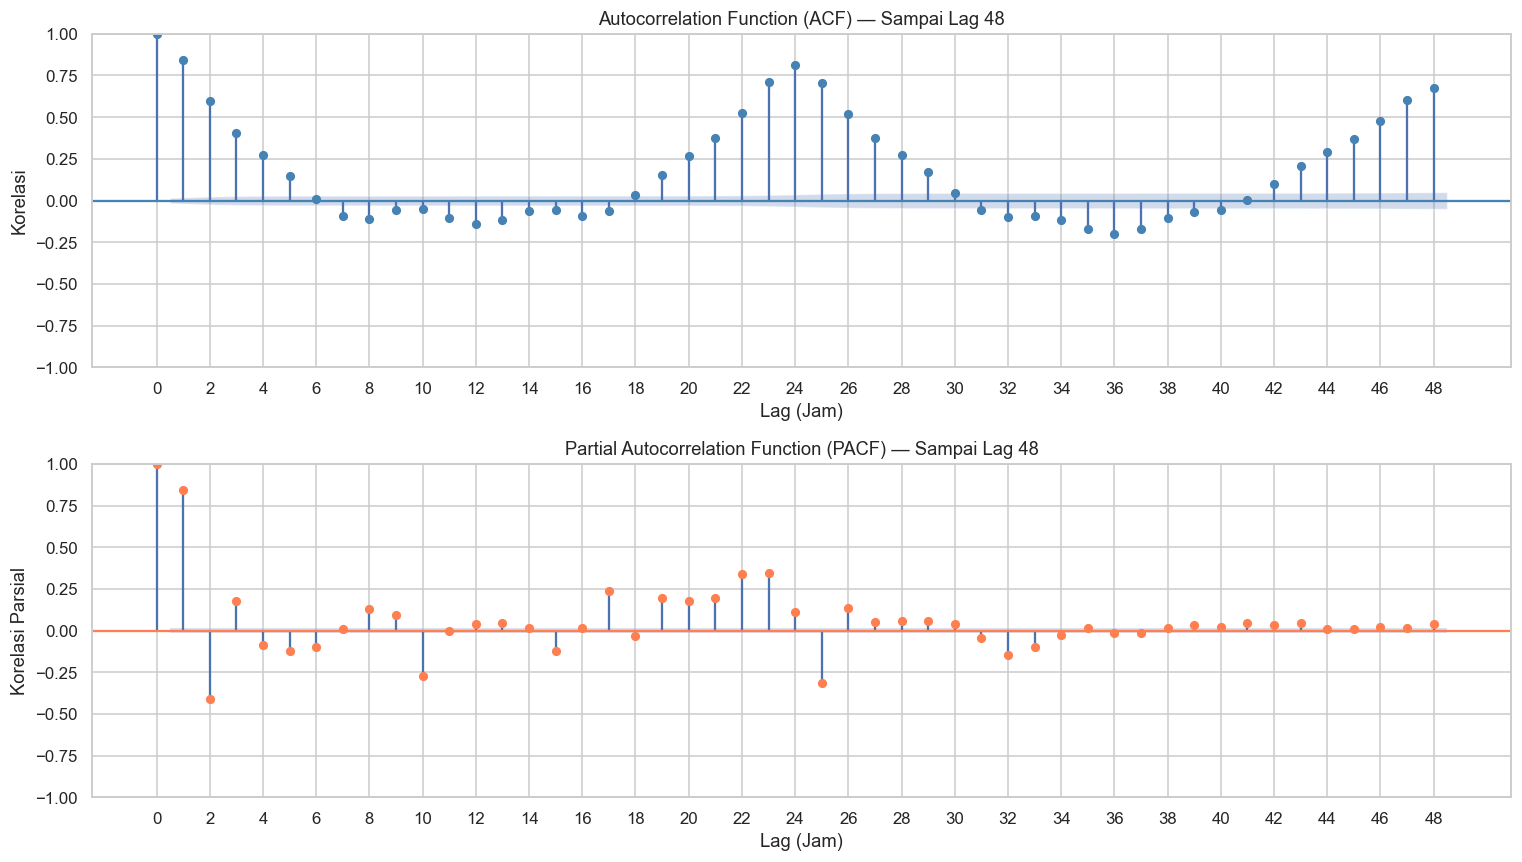

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF plot (sampai lag 48 untuk melihat pola harian)
plot_acf(df['cnt'], lags=48, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF) — Sampai Lag 48')
axes[0].set_xlabel('Lag (Jam)')
axes[0].set_ylabel('Korelasi')
axes[0].set_xticks(range(0, 49, 2))

# PACF plot dengan method='yw'
plot_pacf(df['cnt'], lags=48, ax=axes[1], color='coral', alpha=0.05, method='yw')
axes[1].set_title('Partial Autocorrelation Function (PACF) — Sampai Lag 48')
axes[1].set_xlabel('Lag (Jam)')
axes[1].set_ylabel('Korelasi Parsial')
axes[1].set_xticks(range(0, 49, 2))

plt.tight_layout()
plt.savefig('../data/diagnostics_04_acf_pacf.png', bbox_inches='tight', dpi=110)
plt.show()

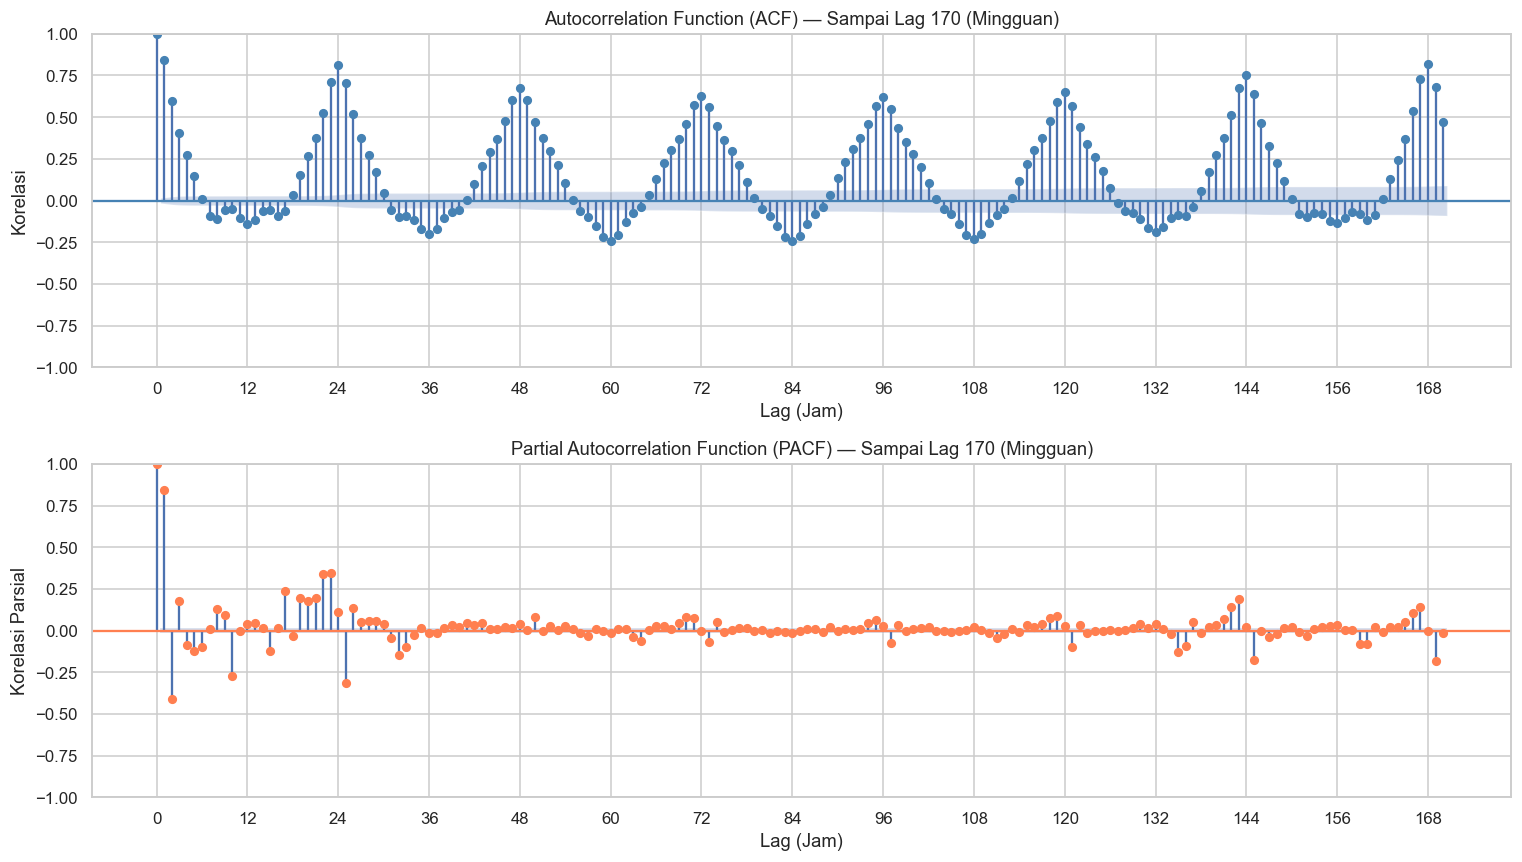

In [8]:
# ACF & PACF dengan lag mingguan (sampai 170 jam) untuk mendeteksi pola mingguan
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df['cnt'], lags=170, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF) — Sampai Lag 170 (Mingguan)')
axes[0].set_xlabel('Lag (Jam)')
axes[0].set_ylabel('Korelasi')
axes[0].set_xticks(range(0, 171, 12))

plot_pacf(df['cnt'], lags=170, ax=axes[1], color='coral', alpha=0.05, method='yw')
axes[1].set_title('Partial Autocorrelation Function (PACF) — Sampai Lag 170 (Mingguan)')
axes[1].set_xlabel('Lag (Jam)')
axes[1].set_ylabel('Korelasi Parsial')
axes[1].set_xticks(range(0, 171, 12))

plt.tight_layout()
plt.savefig('../data/diagnostics_05_acf_pacf_weekly.png', bbox_inches='tight', dpi=110)
plt.show()

**Interpretasi:**

- **Pola Siklus pada ACF**: Grafik ACF menunjukkan pola gelombang sinusoidal yang berulang setiap **24 jam** dan **168 jam (7 hari)**. Ini adalah bukti kuat adanya pola musiman harian dan mingguan.
- **PACF Significance**: PACF terpotong tajam setelah lag-lag awal, tetapi menunjukkan lonjakan signifikan kembali pada **lag 24, 25, 48**, dan **168**.
- **Konfirmasi Lag Order**: Hasil ini menjustifikasi pemilihan lag features pada EXP-004, yaitu:
  - Lag jangka pendek: `cnt_lag_1`, `cnt_lag_2`, `cnt_lag_3`
  - Lag musiman: `cnt_lag_24` (kemarin) dan `cnt_lag_168` (seminggu lalu)

---

## 8. Time Series Decomposition

Memisahkan data target `cnt` menjadi komponen pembentuknya: **Trend**, **Seasonal**, dan **Residual** menggunakan model dekomposisi aditif.

Karena data per jam terlalu rapat untuk divisualisasikan secara langsung (17.379 baris), kita lakukan dekomposisi terhadap data harian agar visualisasinya lebih jelas.

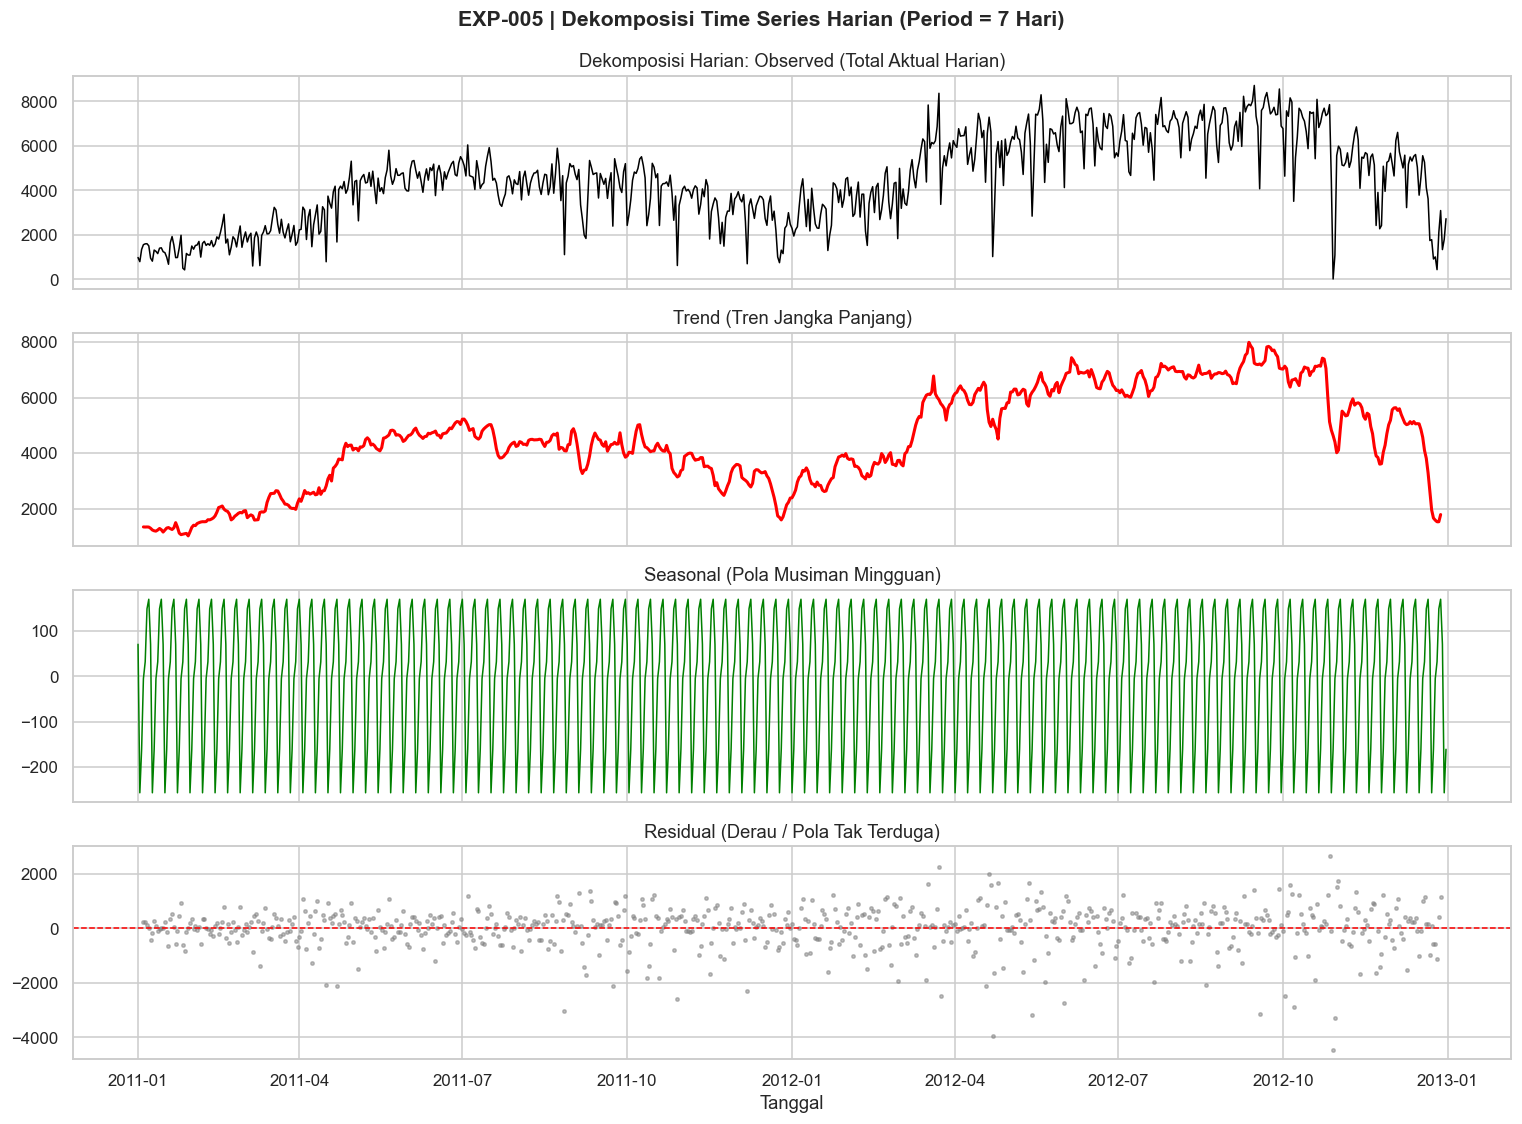

In [9]:
# Resample data ke harian untuk visualisasi dekomposisi yang jelas
df_daily = df.set_index('dteday').resample('D')['cnt'].sum().to_frame()

# Dekomposisi dengan period = 7 (musiman mingguan untuk data harian)
decomp = seasonal_decompose(df_daily['cnt'], model='additive', period=7)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_daily.index, decomp.observed, color='black', linewidth=1)
axes[0].set_title('Dekomposisi Harian: Observed (Total Aktual Harian)')

axes[1].plot(df_daily.index, decomp.trend, color='red', linewidth=2)
axes[1].set_title('Trend (Tren Jangka Panjang)')

axes[2].plot(df_daily.index, decomp.seasonal, color='green', linewidth=1)
axes[2].set_title('Seasonal (Pola Musiman Mingguan)')

axes[3].scatter(df_daily.index, decomp.resid, color='gray', s=5, alpha=0.5)
axes[3].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[3].set_title('Residual (Derau / Pola Tak Terduga)')
axes[3].set_xlabel('Tanggal')

plt.tight_layout()
plt.suptitle('EXP-005 | Dekomposisi Time Series Harian (Period = 7 Hari)', fontsize=14, y=1.02, fontweight='bold')
plt.savefig('../data/diagnostics_06_decomposition.png', bbox_inches='tight', dpi=110)
plt.show()

**Interpretasi:**

- **Observed**: Data aktual harian penyewaan sepeda.
- **Trend**: Menunjukkan tren jangka panjang yang naik-turun berdasarkan musim makro (puncak di pertengahan tahun) dan secara bertahap merangkak naik dari 2011 ke 2012.
- **Seasonal**: Menangkap pola fluktuasi mingguan (periode 7 hari) yang konsisten.
- **Residual**: Sisa varians yang tidak terjelaskan oleh tren dan seasonal. Ditemukan beberapa lonjakan residual negatif yang kuat (misalnya menjelang akhir tahun 2012) — ini berkorelasi dengan kejadian ekstrim seperti Badai Sandy pada Oktober 2012.

---

## 9. Initial Findings

Ringkasan karakteristik time series berdasarkan hasil diagnostik:

### 9.1 Karakteristik Temporal

- ✅ **Tren Jangka Panjang**: Teridentifikasi tren kenaikan bertahap dari tahun 2011 ke 2012, serta tren musiman makro berbentuk pola lonceng terbalik dalam siklus tahunan.
- ✅ **Multivariat Seasonality**: Pola musiman terbukti sangat kuat pada beberapa skala waktu:
  - Pola harian (24 jam): dipengaruhi jenis hari (kerja vs libur).
  - Pola mingguan (7 hari): fluktuasi antar hari dalam seminggu.
  - Pola bulanan/musim (tahunan): fluktuasi cuaca/suhu musiman.

---

### 9.2 Stasioneritas & Autokorelasi

- ✅ **Stasioneritas**: Augmented Dickey-Fuller Test menghasilkan p-value $0.00 \times 10^0$ (stasioner secara statistik). Hal ini menunjukkan data berfluktuasi secara konstan di sekitar mean global jangka panjang, namun varians dan tren lokal tidak konstan.
- ✅ **Autokorelasi Kuat**: ACF & PACF mengonfirmasi adanya ketergantungan waktu yang tinggi terhadap observasi sebelumnya. Lonjakan korelasi terbesar berada pada **lag 1, 24, dan 168**.

---

### 9.3 Rekomendasi Pemodelan

1. **Model Non-Linear Robust**: Model berbasis pohon (Random Forest, Gradient Boosting, XGBoost) sangat direkomendasikan karena dapat menangkap hubungan non-linear tren, musim, dan cuaca tanpa perlu transformasi differencing yang rumit.
2. **Pemanfaatan Lag Features**: Penggunaan `cnt_lag_1` (1 jam lalu) dan `cnt_lag_24` (jam yang sama kemarin) akan menjadi prediktor yang sangat kuat dalam model regresi.

---

## 10. Next Step

---

### Eksperimen Berikutnya

| Informasi | Detail |
|-----------|--------|
| **ID** | EXP-006 |
| **Nama** | Baseline Forecasting |
| **Notebook** | `06_baseline_model.ipynb` |
| **Input** | `data/featured_data.csv` |

**Tujuan:**

> Membangun model baseline sederhana sebagai pembanding utama bagi seluruh model machine learning berikutnya.

**Model yang akan dibuat pada EXP-006:**

- **Naive Forecast**: Prediksi jam berikutnya adalah nilai jam saat ini ($y_{t+1} = y_t$).
- **Moving Average Forecast**: Prediksi jam berikutnya adalah rata-rata $N$ jam terakhir.
- Perhitungan metrik evaluasi standar: **MAE**, **RMSE**, dan **MAPE**.

---

*Notebook EXP-005 Time Series Diagnostics — Selesai.*